# Customer Churn Prediction — Olist E-commerce Dataset

## Project Overview

Customer churn is one of the most critical problems for e-commerce companies. Acquiring new customers is significantly more expensive than retaining existing ones. Therefore, identifying customers who are likely to churn enables companies to take proactive actions such as targeted promotions, personalized offers, or improved customer experience.

In this project, we build a **customer-level churn prediction model** using the Olist Brazilian E-commerce dataset.

The project pipeline includes:

- Customer-level feature engineering
- RFM and CLV feature integration
- Exploratory Data Analysis (EDA)
- Feature selection
- Machine learning model training
- Churn probability prediction

The final model predicts whether a customer is likely to churn and estimates their churn probability.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql
import math
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# 1. Creating the Customer-Level Dataset

The raw transactional dataset is aggregated at the **customer level** in order to build a churn prediction dataset.

Several feature groups are created:

- Transaction features
- Time-based features
- Delivery experience features
- Review and sentiment features
- RFM metrics
- CLV predictions

This transformation converts **order-level data into customer behavioral profiles**, which are suitable for churn modeling.

In [3]:
## SQL Connection
conn = pymysql.connect(database = "olist", user = "root", password = "160510", local_infile=True)
cursor = conn.cursor()

In [4]:
df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)
df_all.head()

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\383586695.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)


,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15 00:00:00,perfumery\r,perfumery\r,1,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1,Single,garden_tools\r,varzea paulista,SP


In [5]:
# Editing the data type of the date columns:
date_cols = ["purchase_ts","approved_ts","carrier_ts","delivered_ts","review_creation_date"]
for c in date_cols:
    if c in df_all.columns:
        df_all[c] = pd.to_datetime(df_all[c], errors="coerce")

In [8]:
cat_cols = ["main_category_by_item","main_category_by_revenue","order_type","all_categories"]
for c in cat_cols:
    if c in df_all.columns:
        df_all[c] = df_all[c].astype(str).str.replace(r"[\r\n\t]", "", regex=True).str.strip()

## Transaction Features

Transaction features capture customers' purchasing behavior.

These features include:

- total number of orders
- total revenue generated
- average order value
- total purchased items
- number of unique product categories
- average items per order

These variables help us understand **customer purchase intensity and value contribution**.


In [10]:
cust_tf = df_all.groupby("customer_unique_id").agg(
    total_orders = ("order_id", "nunique"),
    total_revenues = ("total_payment", "sum"),
    avg_order_value=("total_payment","mean"),
    total_items = ("item_count", "sum"),
    unique_categories = ("main_category_by_revenue", "nunique")
)

cust_tf["avg_items_per_order"] = cust_tf["total_items"] / cust_tf["total_orders"]
cust_tf["is_repeat_customer"] = (cust_tf["total_orders"] > 1).astype(int)


In [11]:
cust_tf.head()

,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90000,141.90000,1,1,1.00000,0
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19000,27.19000,1,1,1.00000,0
0000f46a3911fa3c0805444483337064,1,86.22000,86.22000,1,1,1.00000,0
0000f6ccb0745a6a4b88665a16c9f078,1,43.62000,43.62000,1,1,1.00000,0
0004aac84e0df4da2b147fca70cf8255,1,196.89000,196.89000,1,1,1.00000,0


## Time Features

Time-based features measure the **customer lifecycle and purchasing intervals**.

Key metrics include:

- first purchase date
- last purchase date
- customer lifetime (`customer_age_days`)
- days since last purchase
- average days between orders

These variables are critical signals for churn prediction since **inactive customers are more likely to churn**.


In [13]:
analysis_date = df_all["purchase_ts"].max() + pd.Timedelta(days=1)

cust_time = df_all.groupby("customer_unique_id").agg(
    first_purchase = ("purchase_ts", "min"),
    last_purchase = ("purchase_ts", "max"),
    total_orders = ("order_id", "nunique")
)

cust_time["customer_age_days"] = (analysis_date - cust_time["first_purchase"]).dt.days

cust_time["days_since_last_purchase"] = (analysis_date - cust_time["last_purchase"]).dt.days

cust_time["avg_days_between_orders"] = (cust_time["customer_age_days"] / cust_time["total_orders"])

cust_time.drop("total_orders", axis=1, inplace=True)



In [14]:
cust_time.head()

,first_purchase,last_purchase,customer_age_days,days_since_last_purchase,avg_days_between_orders
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,112,112,112.00000
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,115,115,115.00000
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,537,537,537.00000
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,321,321,321.00000
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,288,288,288.00000


## Delivery Experience Features

Customer satisfaction in e-commerce is strongly influenced by delivery performance.

Delivery-related metrics include:

- average delivery time
- late delivery ratio

Poor delivery experiences often increase churn probability.

In [16]:
cust_delivery = df_all.groupby("customer_unique_id").agg(
    avg_delivery_days=("days_to_deliver","mean"),
    late_delivery_ratio=("is_late","mean")
)

In [17]:
cust_delivery.head()

,avg_delivery_days,late_delivery_ratio
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,6.00000,0.00000
0000b849f77a49e4a4ce2b2a4ca5be3f,3.00000,0.00000
0000f46a3911fa3c0805444483337064,26.00000,0.00000
0000f6ccb0745a6a4b88665a16c9f078,20.00000,0.00000
0004aac84e0df4da2b147fca70cf8255,13.00000,0.00000


## Review Features

Customer reviews provide insights into customer satisfaction.

The following review-based features are calculated:

- average review score
- number of reviews
- number of negative reviews
- negative review ratio

Customers who experience dissatisfaction tend to leave negative reviews and may eventually churn.

In [19]:
cust_reviews = df_all.groupby("customer_unique_id").agg(
    avg_review_score=("review_score", "mean"),
    total_reviews=("review_score", "count"),
    negative_reviews=("review_score", 
                      lambda x: (x <= 2).sum() if x.notna().any() else np.nan)
)

cust_reviews["negative_review_ratio"] = (
    cust_reviews["negative_reviews"] / cust_reviews["total_reviews"]
)

In [20]:
cust_reviews.head()

,avg_review_score,total_reviews,negative_reviews,negative_review_ratio
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,5.00000,1,0.00000,0.00000
0000b849f77a49e4a4ce2b2a4ca5be3f,4.00000,1,0.00000,0.00000
0000f46a3911fa3c0805444483337064,3.00000,1,0.00000,0.00000
0000f6ccb0745a6a4b88665a16c9f078,4.00000,1,0.00000,0.00000
0004aac84e0df4da2b147fca70cf8255,5.00000,1,0.00000,0.00000


## RFM Features

RFM analysis summarizes customer purchasing behavior using three metrics:

- **Recency** – how recently the customer purchased
- **Frequency** – how often the customer purchases
- **Monetary** – how much the customer spends

RFM metrics are widely used in **customer segmentation and churn analysis**.

In [22]:
rfm_df = pd.read_sql("SELECT * FROM rfm_customer_segments", conn)
rfm_df.head()

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\1297714996.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rfm_df = pd.read_sql("SELECT * FROM rfm_customer_segments", conn)


,customer_unique_id,recency_days,frequency,monetary,last_purchase,aov,recency_score,frequency_score,monetary_score,RFM_SCORE,segment,log_monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000,2018-05-10 10:56:27,141.90000,4,1,4,41,promising,4.96214
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000,2018-05-07 11:11:27,27.19000,4,1,1,41,promising,3.33897
2,0000f46a3911fa3c0805444483337064,537,1,86.22000,2017-03-10 21:05:03,86.22000,1,1,3,11,hibernating,4.46843
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000,2017-10-12 20:29:41,43.62000,2,1,1,21,hibernating,3.79818
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89000,2017-11-14 19:45:42,196.89000,2,1,4,21,hibernating,5.28771


In [25]:
rfm_df=rfm_df[["customer_unique_id", "recency_days", "frequency", "monetary"]].copy()
rfm_df.set_index("customer_unique_id", inplace=True)
rfm_df.head()

,recency_days,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90000
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19000
0000f46a3911fa3c0805444483337064,537,1,86.22000
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62000
0004aac84e0df4da2b147fca70cf8255,288,1,196.89000


## CLV Features

Customer Lifetime Value models estimate future purchasing behavior.

In this project, we incorporate:

- expected number of purchases in the next month

This feature helps the model understand **future customer potential**.


In [34]:
clv_df = pd.read_sql("SELECT * FROM nbd_summary", conn)
clv_df.head()

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\246900831.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  clv_df = pd.read_sql("SELECT * FROM nbd_summary", conn)


,customer_unique_id,frequency,recency,T,monetary_value,expected_purc_1_week,expected_purc_1_month,expected_purc_3_month
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00000,0.00000,15.85714,0.00000,0.00062,0.00236,0.00637
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00000,0.00000,16.28571,0.00000,0.00061,0.00232,0.00628
2,0000f46a3911fa3c0805444483337064,0.00000,0.00000,76.71429,0.00000,0.00019,0.00074,0.00213
3,0000f6ccb0745a6a4b88665a16c9f078,0.00000,0.00000,45.85714,0.00000,0.00029,0.00113,0.00321
4,0004aac84e0df4da2b147fca70cf8255,0.00000,0.00000,41.14286,0.00000,0.00032,0.00123,0.00348


In [35]:
clv_df=clv_df[["customer_unique_id", "expected_purc_1_month"]].copy()
clv_df.set_index("customer_unique_id", inplace=True)
clv_df.head()

,expected_purc_1_month
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,0.00236
0000b849f77a49e4a4ce2b2a4ca5be3f,0.00232
0000f46a3911fa3c0805444483337064,0.00074
0000f6ccb0745a6a4b88665a16c9f078,0.00113
0004aac84e0df4da2b147fca70cf8255,0.00123


In [36]:
df = (
    cust_tf
    .join(cust_time)
    .join(cust_delivery)
    .join(cust_reviews)
    .join(rfm_df)
    .join(clv_df)
)

df.head()

,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer,first_purchase,last_purchase,customer_age_days,days_since_last_purchase,avg_days_between_orders,avg_delivery_days,late_delivery_ratio,avg_review_score,total_reviews,negative_reviews,negative_review_ratio,recency_days,frequency,monetary,expected_purc_1_month
customer_unique_id,,,,,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90000,141.90000,1,1,1.00000,0,2018-05-10 10:56:27,2018-05-10 10:56:27,112,112,112.00000,6.00000,0.00000,5.00000,1,0.00000,0.00000,112,1,141.90000,0.00236
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19000,27.19000,1,1,1.00000,0,2018-05-07 11:11:27,2018-05-07 11:11:27,115,115,115.00000,3.00000,0.00000,4.00000,1,0.00000,0.00000,115,1,27.19000,0.00232
0000f46a3911fa3c0805444483337064,1,86.22000,86.22000,1,1,1.00000,0,2017-03-10 21:05:03,2017-03-10 21:05:03,537,537,537.00000,26.00000,0.00000,3.00000,1,0.00000,0.00000,537,1,86.22000,0.00074
0000f6ccb0745a6a4b88665a16c9f078,1,43.62000,43.62000,1,1,1.00000,0,2017-10-12 20:29:41,2017-10-12 20:29:41,321,321,321.00000,20.00000,0.00000,4.00000,1,0.00000,0.00000,321,1,43.62000,0.00113
0004aac84e0df4da2b147fca70cf8255,1,196.89000,196.89000,1,1,1.00000,0,2017-11-14 19:45:42,2017-11-14 19:45:42,288,288,288.00000,13.00000,0.00000,5.00000,1,0.00000,0.00000,288,1,196.89000,0.00123


# Defining the Churn Variable

Churn must be defined based on customer inactivity.

In this project, customers are labeled as churned if they have not made a purchase for more than **90 days**.

churn_threshold = 90 days

This threshold reflects a common inactivity window used in e-commerce churn analysis.

In [37]:
churn_threshold = 90

df["churn"] = (df["days_since_last_purchase"] > churn_threshold).astype(int)
df.head()

,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer,first_purchase,last_purchase,customer_age_days,days_since_last_purchase,avg_days_between_orders,avg_delivery_days,late_delivery_ratio,avg_review_score,total_reviews,negative_reviews,negative_review_ratio,recency_days,frequency,monetary,expected_purc_1_month,churn
customer_unique_id,,,,,,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90000,141.90000,1,1,1.00000,0,2018-05-10 10:56:27,2018-05-10 10:56:27,112,112,112.00000,6.00000,0.00000,5.00000,1,0.00000,0.00000,112,1,141.90000,0.00236,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19000,27.19000,1,1,1.00000,0,2018-05-07 11:11:27,2018-05-07 11:11:27,115,115,115.00000,3.00000,0.00000,4.00000,1,0.00000,0.00000,115,1,27.19000,0.00232,1
0000f46a3911fa3c0805444483337064,1,86.22000,86.22000,1,1,1.00000,0,2017-03-10 21:05:03,2017-03-10 21:05:03,537,537,537.00000,26.00000,0.00000,3.00000,1,0.00000,0.00000,537,1,86.22000,0.00074,1
0000f6ccb0745a6a4b88665a16c9f078,1,43.62000,43.62000,1,1,1.00000,0,2017-10-12 20:29:41,2017-10-12 20:29:41,321,321,321.00000,20.00000,0.00000,4.00000,1,0.00000,0.00000,321,1,43.62000,0.00113,1
0004aac84e0df4da2b147fca70cf8255,1,196.89000,196.89000,1,1,1.00000,0,2017-11-14 19:45:42,2017-11-14 19:45:42,288,288,288.00000,13.00000,0.00000,5.00000,1,0.00000,0.00000,288,1,196.89000,0.00123,1


In [38]:
df["churn"].value_counts()

churn
1    74899
0    18459
Name: count, dtype: int64

In [39]:
df.reset_index(inplace=True)
df.head()

,customer_unique_id,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer,first_purchase,last_purchase,customer_age_days,days_since_last_purchase,avg_days_between_orders,avg_delivery_days,late_delivery_ratio,avg_review_score,total_reviews,negative_reviews,negative_review_ratio,recency_days,frequency,monetary,expected_purc_1_month,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90000,141.90000,1,1,1.00000,0,2018-05-10 10:56:27,2018-05-10 10:56:27,112,112,112.00000,6.00000,0.00000,5.00000,1,0.00000,0.00000,112,1,141.90000,0.00236,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19000,27.19000,1,1,1.00000,0,2018-05-07 11:11:27,2018-05-07 11:11:27,115,115,115.00000,3.00000,0.00000,4.00000,1,0.00000,0.00000,115,1,27.19000,0.00232,1
2,0000f46a3911fa3c0805444483337064,1,86.22000,86.22000,1,1,1.00000,0,2017-03-10 21:05:03,2017-03-10 21:05:03,537,537,537.00000,26.00000,0.00000,3.00000,1,0.00000,0.00000,537,1,86.22000,0.00074,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62000,43.62000,1,1,1.00000,0,2017-10-12 20:29:41,2017-10-12 20:29:41,321,321,321.00000,20.00000,0.00000,4.00000,1,0.00000,0.00000,321,1,43.62000,0.00113,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89000,196.89000,1,1,1.00000,0,2017-11-14 19:45:42,2017-11-14 19:45:42,288,288,288.00000,13.00000,0.00000,5.00000,1,0.00000,0.00000,288,1,196.89000,0.00123,1


# 2. Data Cleaning

Before modeling, the dataset is checked for:

- missing values
- incorrect data types
- duplicate records
- unnecessary columns

Irrelevant variables such as IDs and timestamps are removed to avoid **data leakage**.

In [41]:
def check_df(dataframe, head=5):
    print("################# Shape ##################")
    print(dataframe.shape)
    print("################# Types ##################")
    print(dataframe.dtypes)
    print("################# Head ##################")
    print(dataframe.head(head))
    print("################# Tail ##################")
    print(dataframe.head(head))
    print("################# NA ##################")
    print(dataframe.isnull().sum())
    print("################# Quantiles ##################")
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

In [42]:
check_df(df)

################# Shape ##################
(93358, 24)
################# Types ##################
customer_unique_id                  object
total_orders                         int64
total_revenues                     float64
avg_order_value                    float64
total_items                          int64
unique_categories                    int64
avg_items_per_order                float64
is_repeat_customer                   int32
first_purchase              datetime64[ns]
last_purchase               datetime64[ns]
customer_age_days                    int64
days_since_last_purchase             int64
avg_days_between_orders            float64
avg_delivery_days                  float64
late_delivery_ratio                float64
avg_review_score                   float64
total_reviews                        int64
negative_reviews                   float64
negative_review_ratio              float64
recency_days                         int64
frequency                            int64

In [43]:
df.drop(["customer_unique_id", "first_purchase", "last_purchase"], axis=1, inplace=True)

In [44]:
def grab_col_names(dataframe, cat_th=10, car_th=20):

    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and str(dataframe[col].dtypes) in ["int64", "float64", "int32"]]
    cat_but_car = [col for col in dataframe.columns if
                   dataframe[col].nunique() > car_th and str(dataframe[col].dtypes) in ["category", "object"]]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["int64", "float64", "int32"]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [45]:
cat_cols, num_cols, cat_but_car = grab_col_names(df, cat_th=7, car_th=20)

Observations: 93358
Variables: 21
cat_cols: 4
num_cols: 17
cat_but_car: 0
num_but_cat: 4


# 3. Missing Values Analysis

Missing values are analyzed across all features.

For review-related features:

- customers without reviews are assumed to have **zero negative reviews**
- negative review ratio is filled with **0**

This assumption reflects that **absence of review does not necessarily imply dissatisfaction**.

In [47]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=["n_miss", "ratio"])
    if na_name:
        return missing_df, na_columns
    else:
        return missing_df

In [48]:
missing_df = missing_values_table(df, False)
missing_df

,n_miss,ratio
avg_review_score,633,0.68000
negative_reviews,633,0.68000
negative_review_ratio,633,0.68000
avg_delivery_days,8,0.01000
avg_order_value,1,0.00000


In [49]:
df["negative_reviews"] = df["negative_reviews"].fillna(0)
df["negative_review_ratio"] = df["negative_review_ratio"].fillna(0)
df["avg_review_score"] = df["avg_review_score"].fillna(df["avg_review_score"].median())
df["avg_delivery_days"] = df["avg_delivery_days"].fillna(df["avg_delivery_days"].median())
df["avg_order_value"] = df["avg_order_value"].fillna(df["avg_order_value"].median())

In [50]:
df.isnull().sum()

total_orders                0
total_revenues              0
avg_order_value             0
total_items                 0
unique_categories           0
avg_items_per_order         0
is_repeat_customer          0
customer_age_days           0
days_since_last_purchase    0
avg_days_between_orders     0
avg_delivery_days           0
late_delivery_ratio         0
avg_review_score            0
total_reviews               0
negative_reviews            0
negative_review_ratio       0
recency_days                0
frequency                   0
monetary                    0
expected_purc_1_month       0
churn                       0
dtype: int64

# 4. Outlier Analysis

Numerical variables are inspected using histograms.

Extreme values may distort model learning, especially for variables such as:

- revenue
- delivery time
- purchase frequency

Instead of removing observations, **outlier capping** using percentile thresholds is applied to reduce noise while preserving the dataset size.

In [52]:
def plot_all_histograms(df, num_cols, title_prefix=""):
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

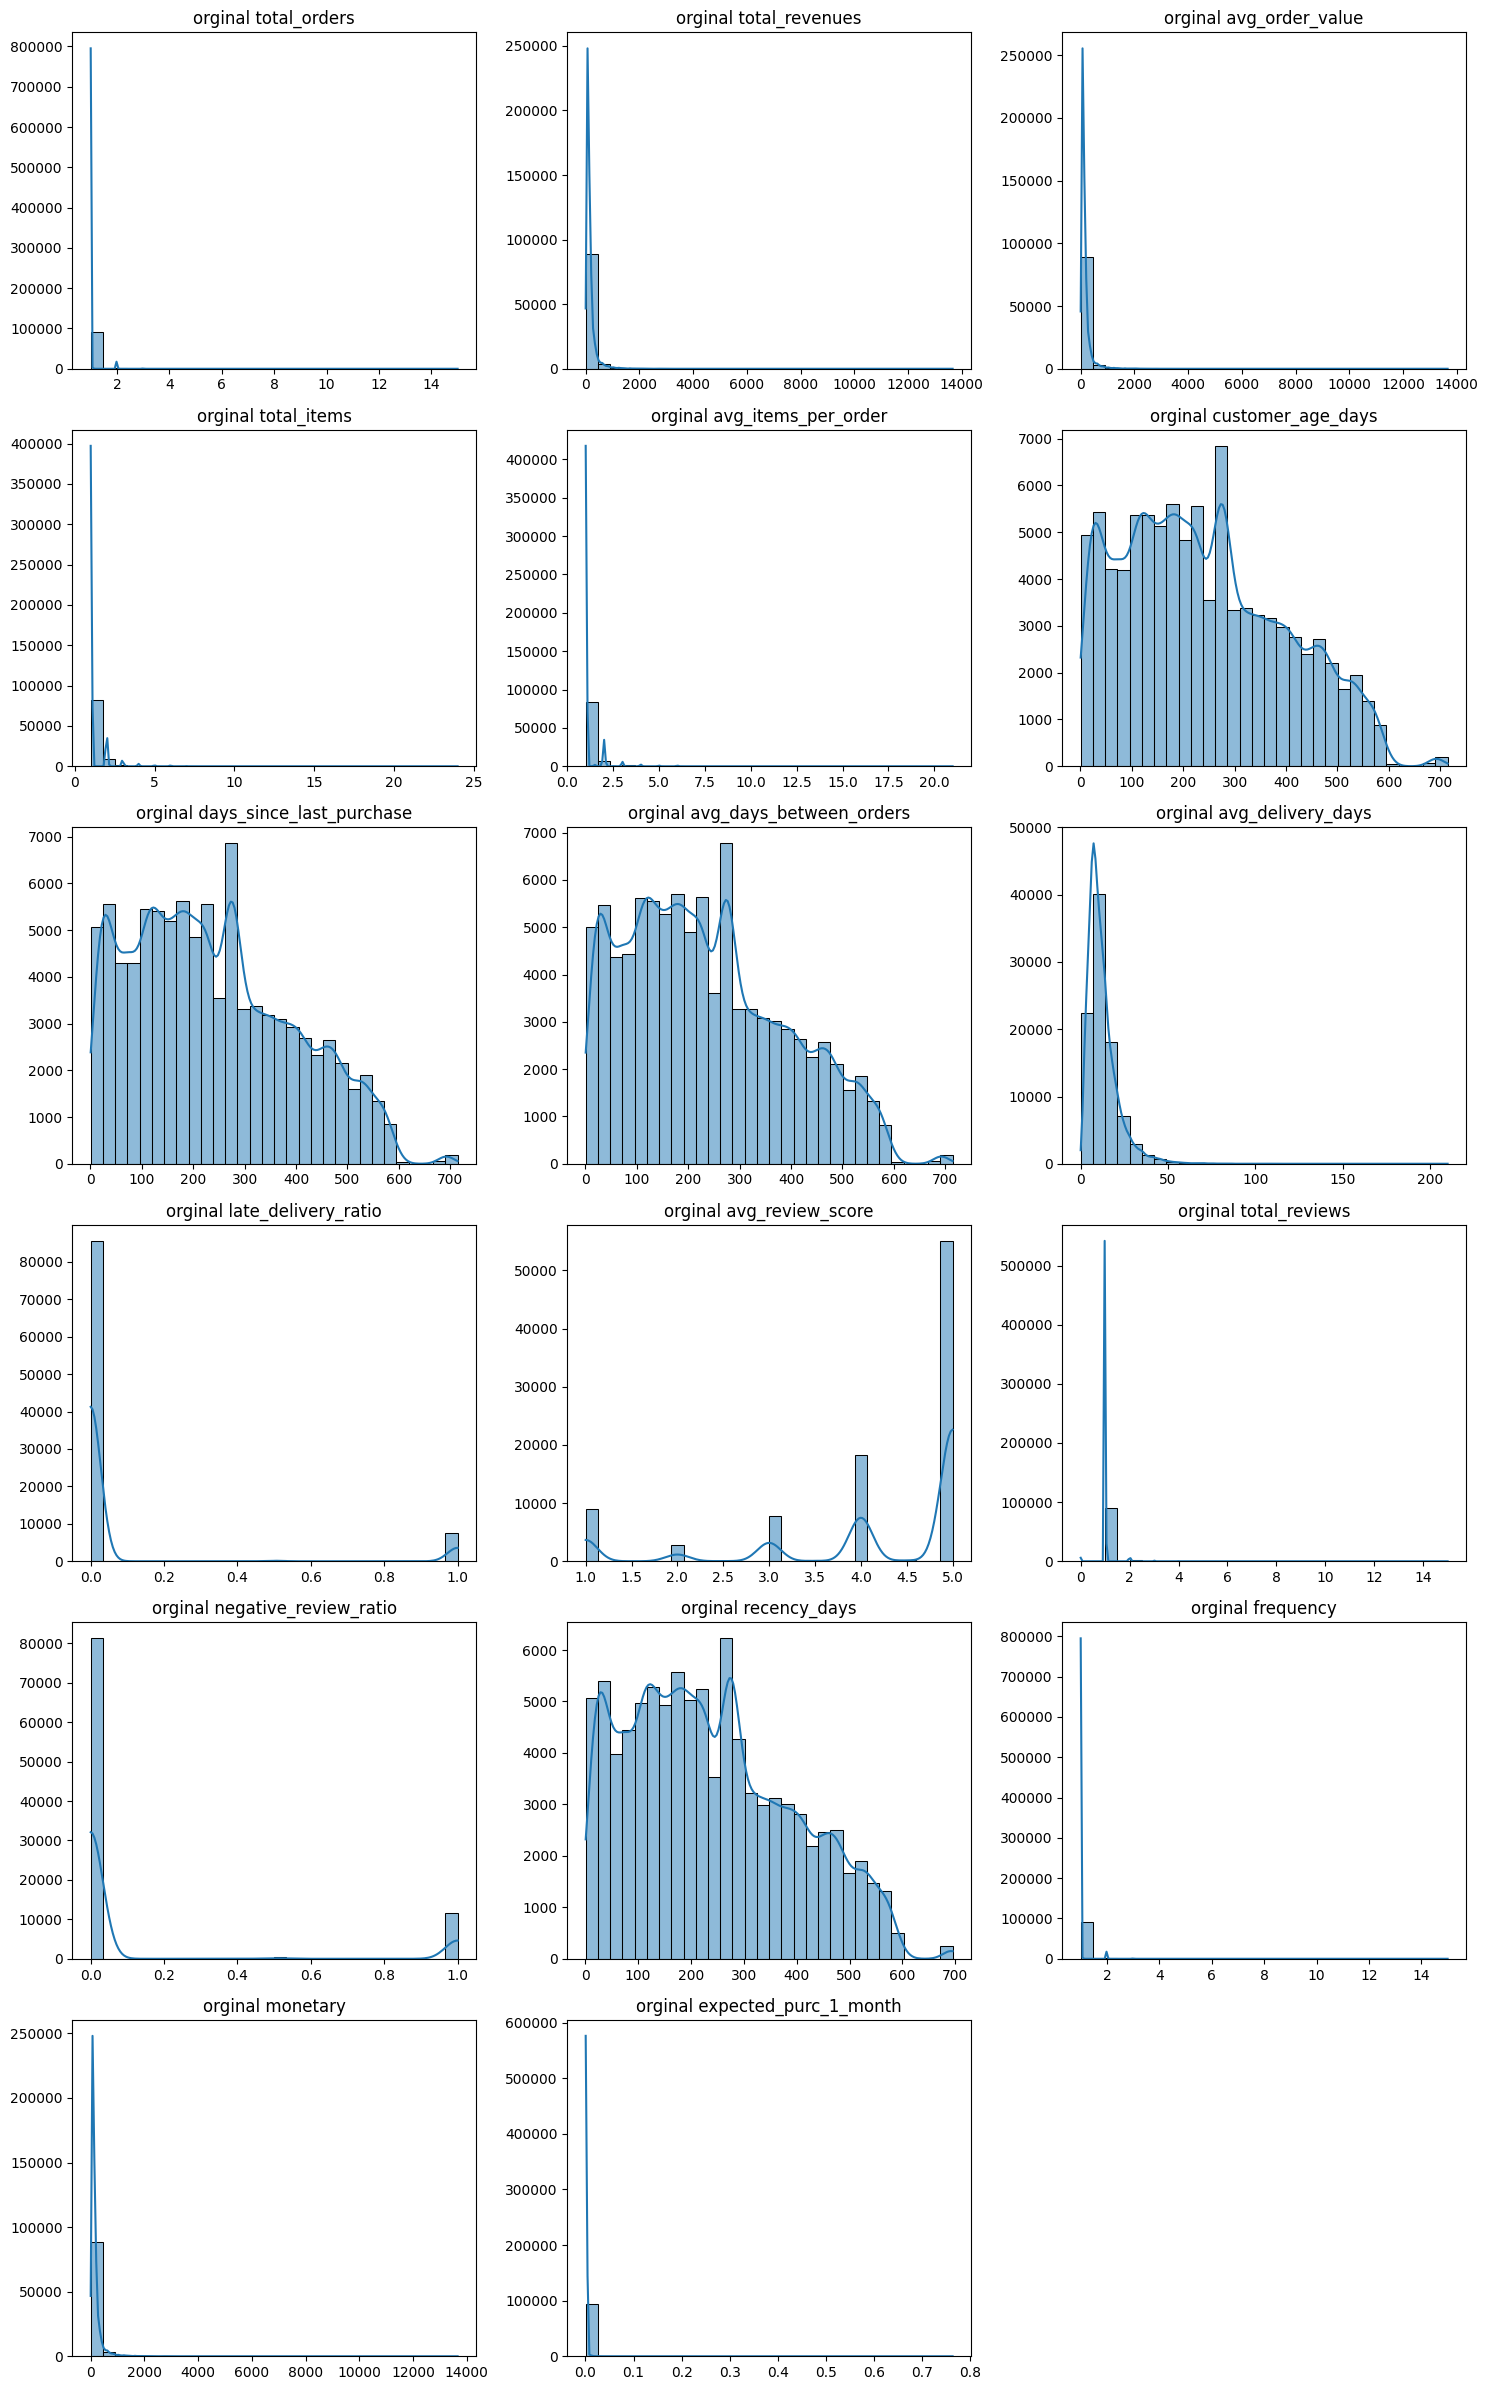

In [53]:
plot_all_histograms(df, num_cols, title_prefix="orginal")

We will use a tree-based model. It will be sufficient for us to slightly trim the outliers.

In [57]:
def outlier_threshold(dataframe, col_name, q1 = 0.01, q3 = 0.99):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interqunatile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interqunatile_range
    low_limit = quartile1 - 1.5 * interqunatile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_threshold(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def replace_with_threshold(dataframe, variable):
    low_limit, up_limit = outlier_threshold(dataframe, variable)
    #dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [58]:
for col in num_cols:
    print(col, check_outlier(df, col))

total_orders True
total_revenues True
avg_order_value True
total_items True
avg_items_per_order True
customer_age_days False
days_since_last_purchase False
avg_days_between_orders False
avg_delivery_days True
late_delivery_ratio False
avg_review_score False
total_reviews True
negative_review_ratio False
recency_days False
frequency True
monetary True
expected_purc_1_month True


In [59]:
for col in num_cols:
    replace_with_threshold(df, col)

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2752709363.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2752709363.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2752709363.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1426.5' has dtype incompatible with int64, please explicitly cast to a compatible d

In [60]:
for col in num_cols:
    print(col, check_outlier(df, col))

total_orders False
total_revenues False
avg_order_value False
total_items False
avg_items_per_order False
customer_age_days False
days_since_last_purchase False
avg_days_between_orders False
avg_delivery_days False
late_delivery_ratio False
avg_review_score False
total_reviews False
negative_review_ratio False
recency_days False
frequency False
monetary False
expected_purc_1_month False


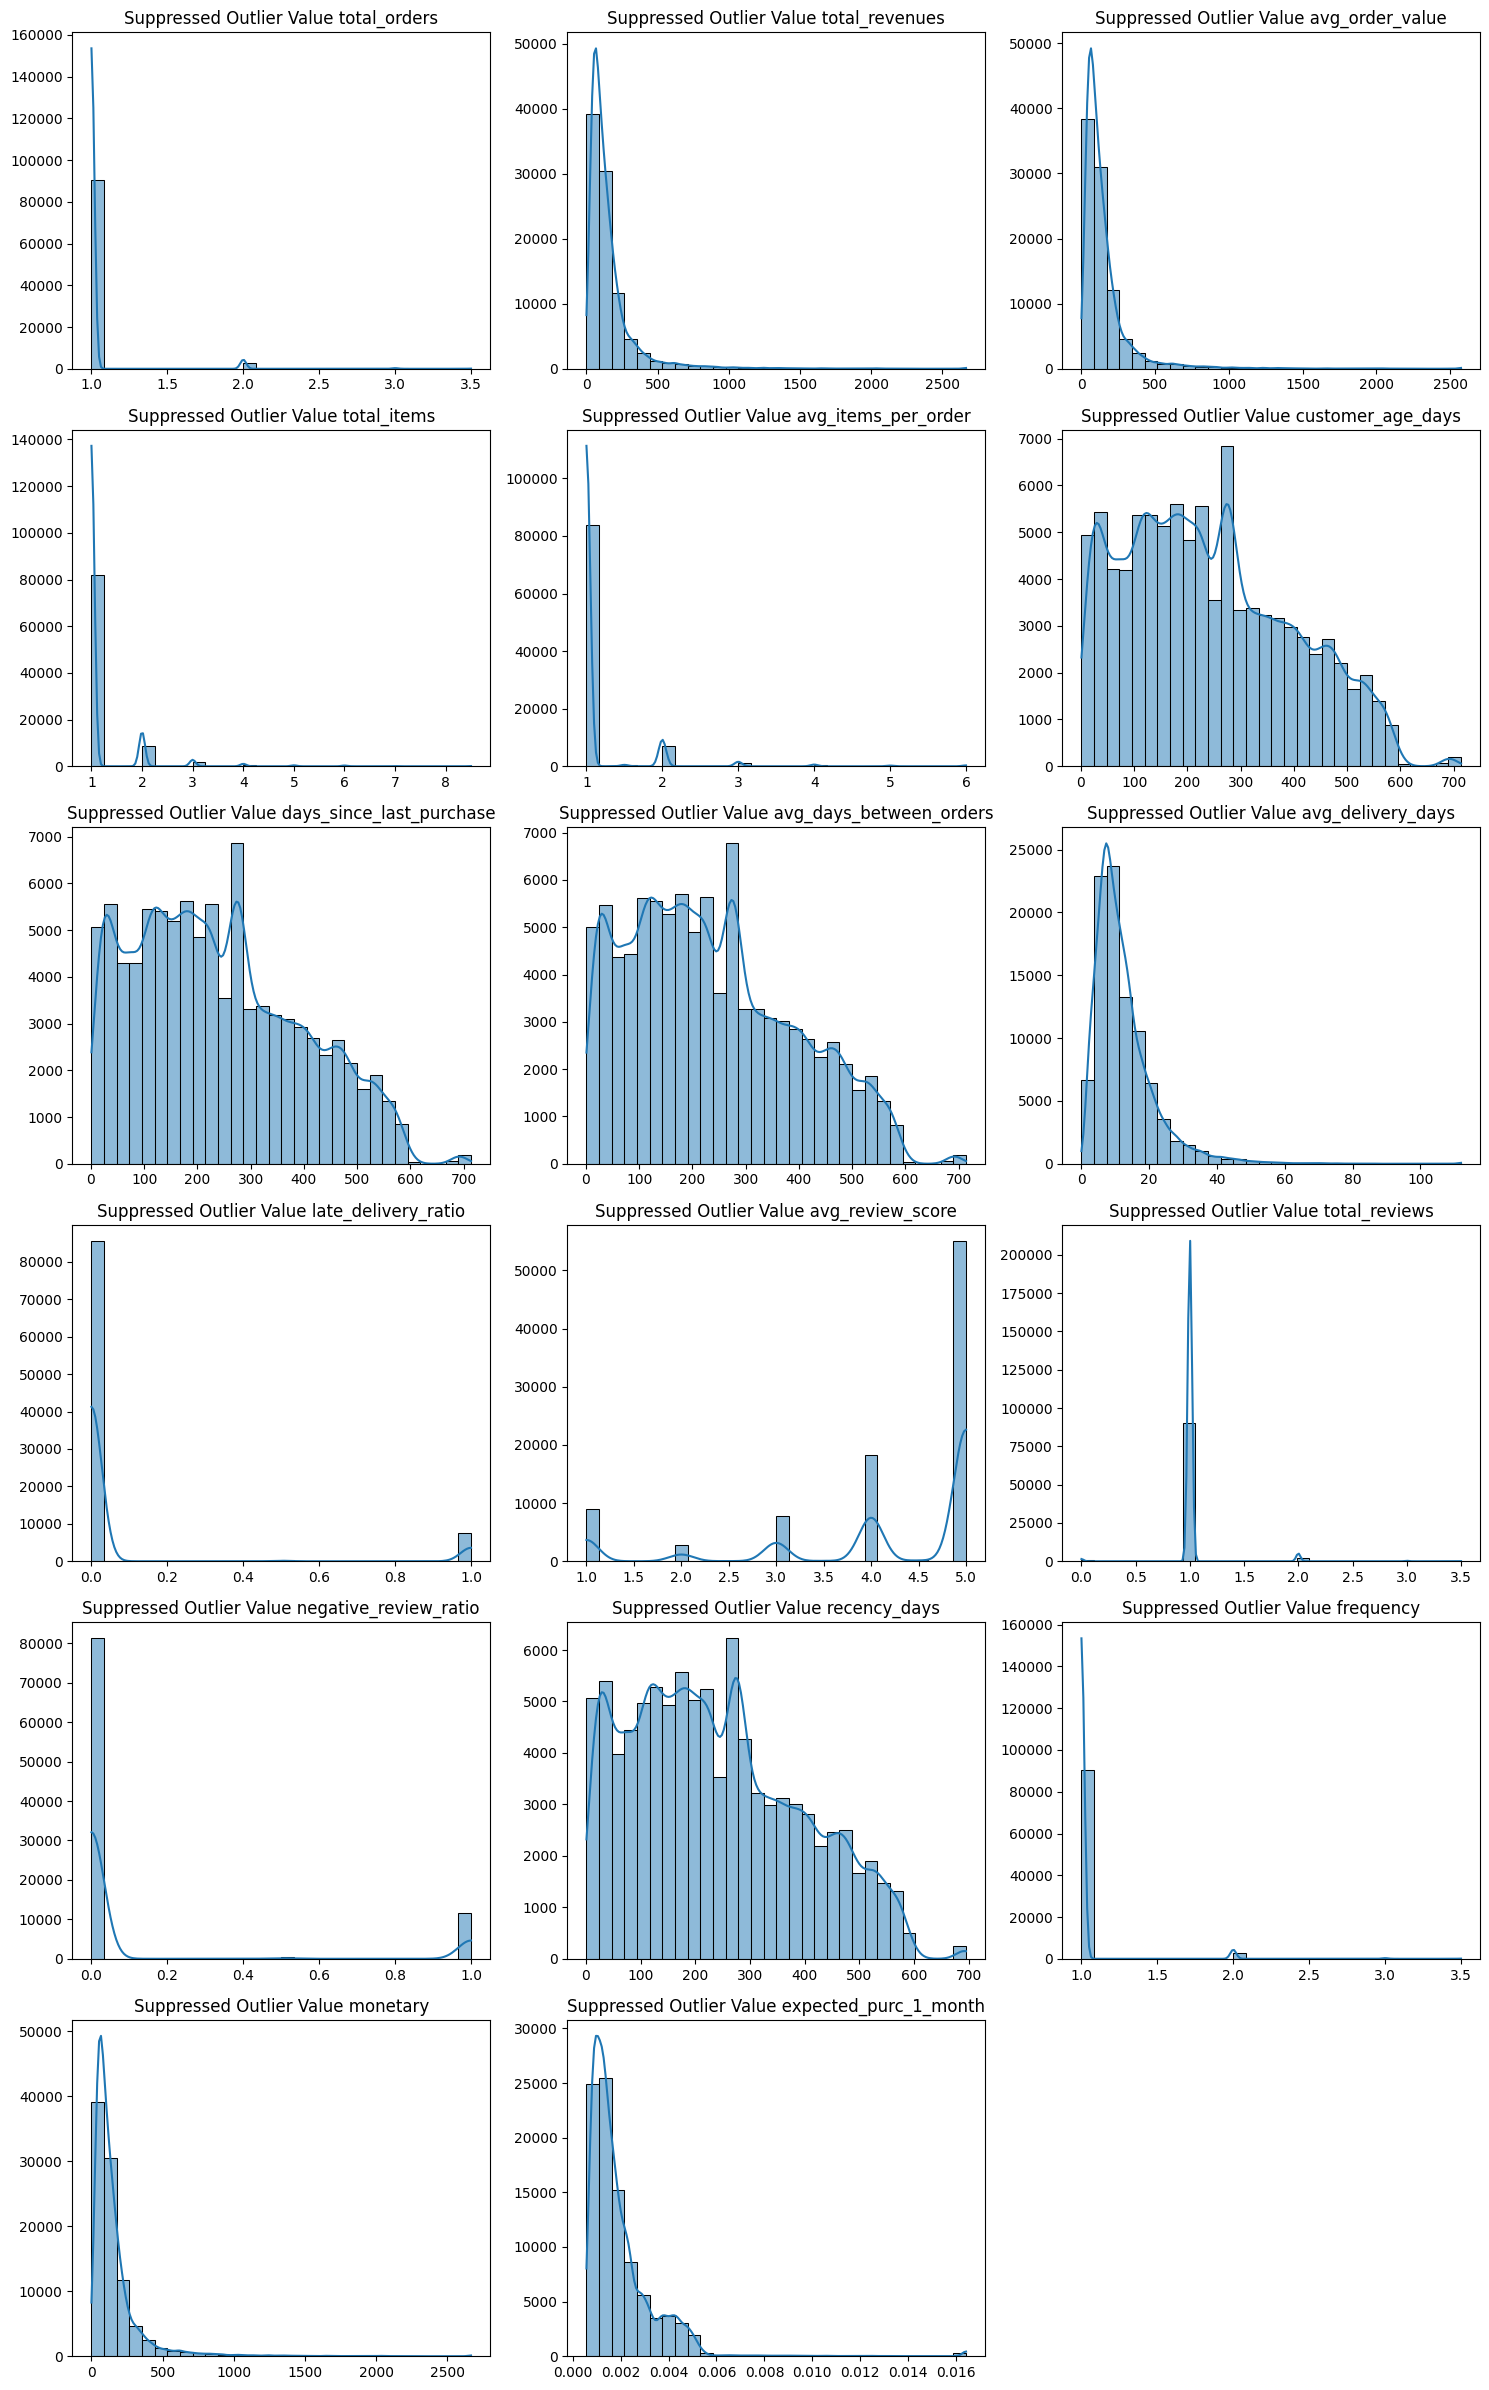

In [79]:
plot_all_histograms(df, num_cols, title_prefix="Suppressed Outlier Value")

# 5. Exploratory Data Analysis

EDA helps us understand how different variables relate to churn behavior.

---

## Target Distribution

The churn distribution shows a strong class imbalance.

A large portion of customers appear to churn because many customers place **only a single order** and never return.

This pattern is common in large e-commerce marketplaces.

In [81]:
df.head()

,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer,customer_age_days,days_since_last_purchase,avg_days_between_orders,avg_delivery_days,late_delivery_ratio,avg_review_score,total_reviews,negative_reviews,negative_review_ratio,recency_days,frequency,monetary,expected_purc_1_month,churn
0,1.00000,141.90000,141.90000,1.00000,1,1.00000,0,112.00000,112,112.00000,6.00000,0.00000,5.00000,1.00000,0.00000,0.00000,112,1.00000,141.90000,0.00236,1
1,1.00000,27.19000,27.19000,1.00000,1,1.00000,0,115.00000,115,115.00000,3.00000,0.00000,4.00000,1.00000,0.00000,0.00000,115,1.00000,27.19000,0.00232,1
2,1.00000,86.22000,86.22000,1.00000,1,1.00000,0,537.00000,537,537.00000,26.00000,0.00000,3.00000,1.00000,0.00000,0.00000,537,1.00000,86.22000,0.00074,1
3,1.00000,43.62000,43.62000,1.00000,1,1.00000,0,321.00000,321,321.00000,20.00000,0.00000,4.00000,1.00000,0.00000,0.00000,321,1.00000,43.62000,0.00113,1
4,1.00000,196.89000,196.89000,1.00000,1,1.00000,0,288.00000,288,288.00000,13.00000,0.00000,5.00000,1.00000,0.00000,0.00000,288,1.00000,196.89000,0.00123,1


In [83]:
df["churn"].value_counts(normalize=True)

churn
1   0.80228
0   0.19772
Name: proportion, dtype: float64

* Churn distribution shows that 80% of customers churned.
* Class imbalance exists and will be taken into account during modeling.

## Numerical Variables vs Churn

### RFM Analysis

RFM metrics show clear patterns:

- churned customers have **higher recency**
- churned customers have **lower frequency**
- churned customers tend to generate **lower monetary value**

These results align with typical churn behavior.

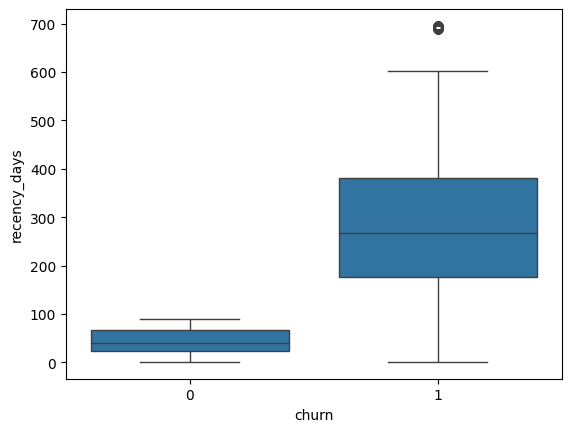

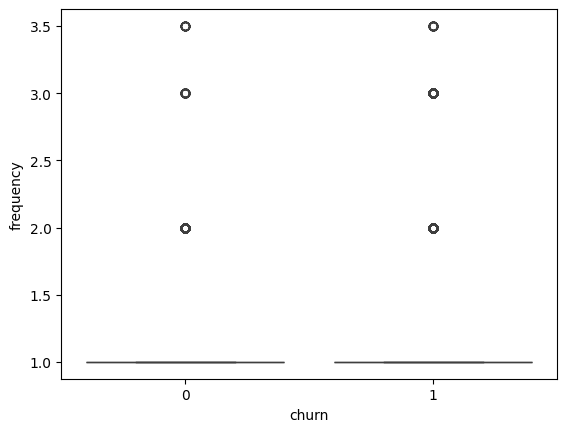

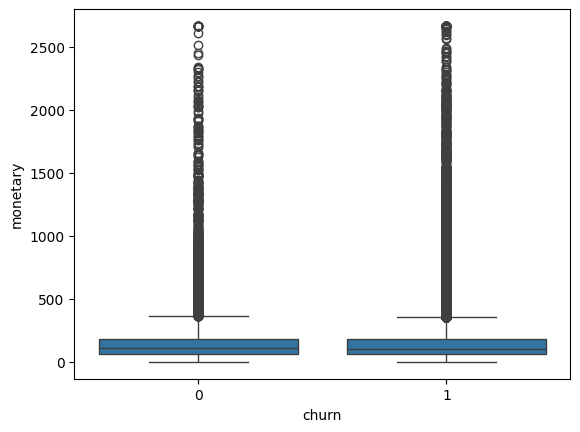

In [86]:
# Churn vs RFM Analysis
rfm_cols = ["recency_days", "frequency", "monetary"]

for col in rfm_cols:
    sns.boxplot(x="churn", y=col, data=df)
    plt.show()

In [87]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target, observed=True).agg({numerical_col: "mean"}), end="\n\n\n")

In [88]:
for col in rfm_cols:
    target_summary_with_num(df, "churn", col)

       recency_days
churn              
0          44.88206
1         285.51218


       frequency
churn           
0        1.03703
1        1.03166


       monetary
churn          
0     164.72557
1     160.94088




* churn customers → high recency

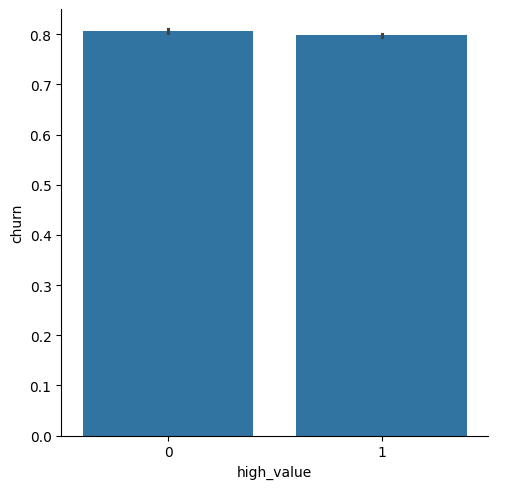

In [95]:
df["high_value"] = (df["monetary"] > df["monetary"].median()).astype(int)

sns.catplot(x="high_value", y="churn", data=df, kind="bar");

* Customers were segmented into high-value and low-value groups  based on the median monetary value.

* The churn rate is very similar across both groups, suggesting that  customer spending alone is not a strong indicator of churn behavior in this dataset.

### Customer Lifetime

Customers with longer inactivity periods tend to churn.

Higher **customer_age_days** combined with low purchasing frequency indicates customer disengagement.

<Axes: xlabel='churn', ylabel='customer_age_days'>

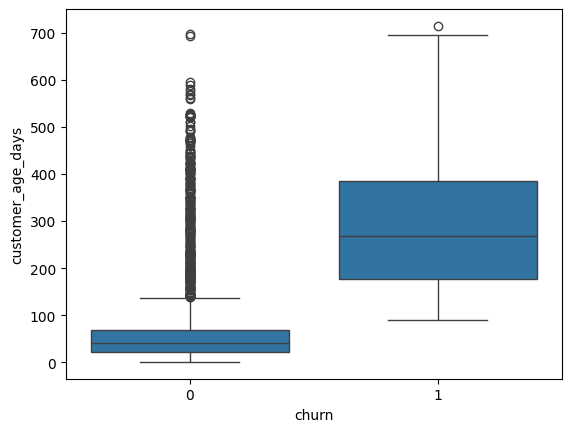

In [97]:
# Customer Lifetime Analysis
sns.boxplot(x="churn", y="customer_age_days", data=df)

* churn customers → high customer age days

### Delivery Experience

Customers experiencing slower delivery times or delays show a slightly higher churn tendency.

Although the effect is moderate, delivery quality remains an important component of customer experience.


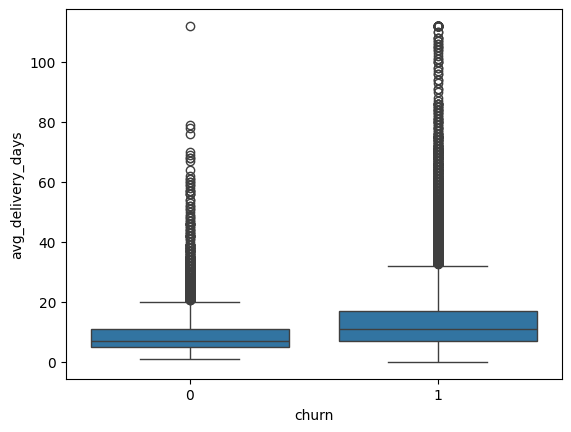

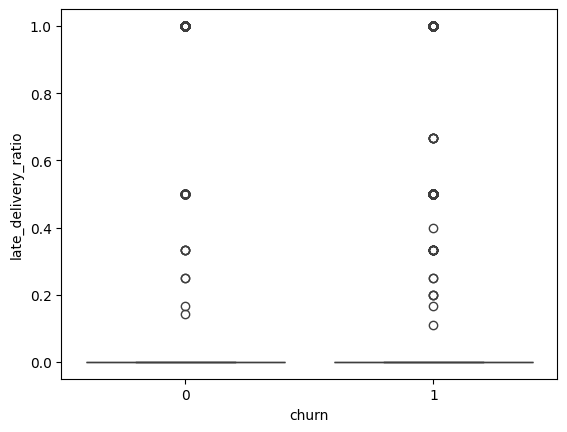

In [99]:
# Delivery Experience Analysis
delivery_cols = ["avg_delivery_days", "late_delivery_ratio"]
for col in delivery_cols:
    sns.boxplot(x="churn", y=col, data=df)
    plt.show()

In [100]:
for col in delivery_cols:
    target_summary_with_num(df, "churn", col)

       avg_delivery_days
churn                   
0                8.61534
1               13.43625


       late_delivery_ratio
churn                     
0                  0.05540
1                  0.08794




* Customers experiencing churn have a higher average delivery time.
* Delivery delays are slightly higher for customers experiencing churn.

### Review and Sentiment

Customers who churn tend to:

- leave more negative reviews
- have lower average review scores

Customer dissatisfaction signals future churn risk.

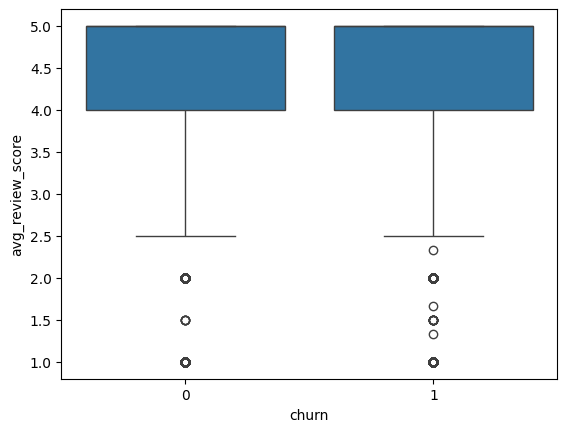

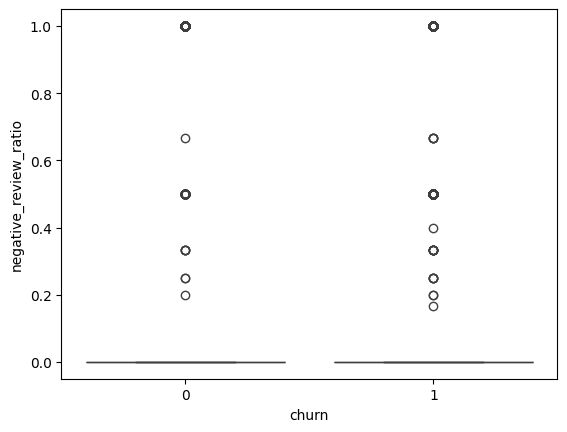

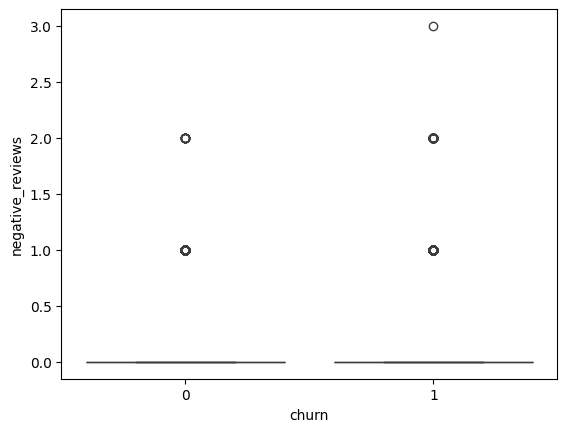

In [102]:
# Review & Sentiment Analysis
sentiment_cols = ["avg_review_score", "negative_review_ratio", "negative_reviews"]
for col in sentiment_cols:
    sns.boxplot(x="churn", y=col, data=df)
    plt.show()

In [103]:
for col in sentiment_cols:
    target_summary_with_num(df, "churn", col)

       avg_review_score
churn                  
0               4.31518
1               4.12162


       negative_review_ratio
churn                       
0                    0.09685
1                    0.13497


       negative_reviews
churn                  
0               0.09979
1               0.13780




* Customers who experience churn have a higher number of negative reviews.

### Order Behavior

Basic order behavior variables such as:

- total orders
- total items
- average items per order

show weaker relationships with churn compared to **recency-based variables**.


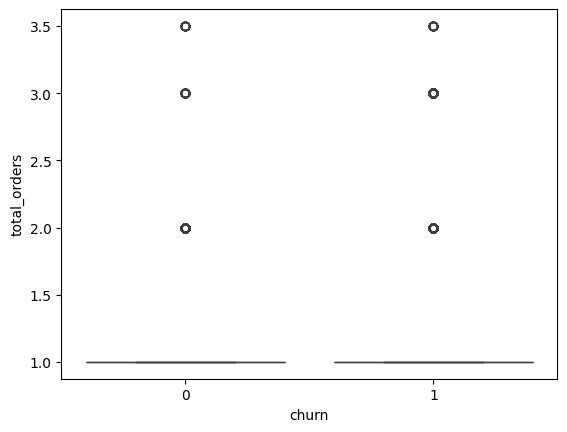

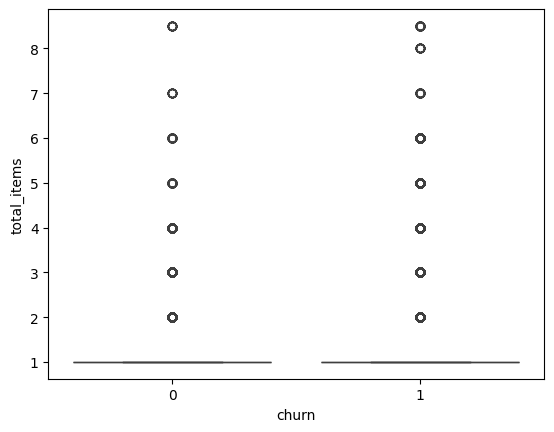

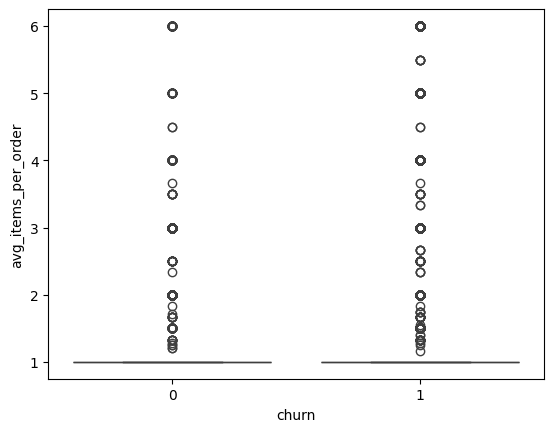

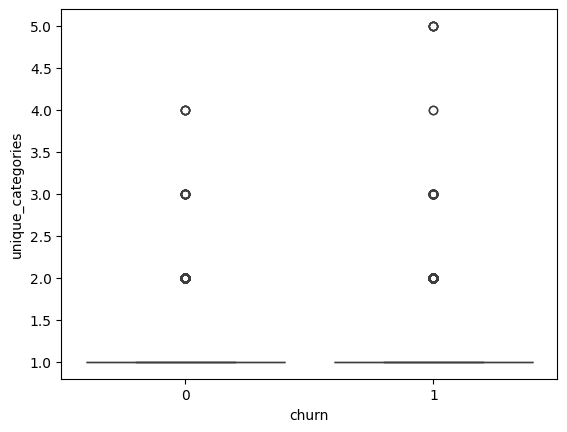

In [105]:
# Order Behavior Analysis
order_behavior_cols = ["total_orders", "total_items", "avg_items_per_order", "unique_categories"]
for col in order_behavior_cols:
    sns.boxplot(x="churn", y=col, data=df)
    plt.show()

In [106]:
for col in order_behavior_cols:
    target_summary_with_num(df, "churn", col)

       total_orders
churn              
0           1.03703
1           1.03163


       total_items
churn             
0          1.17980
1          1.17803


       avg_items_per_order
churn                     
0                  1.13244
1                  1.13875


       unique_categories
churn                   
0                1.02302
1                1.01652




These variables are weak churn predictors.

### CLV Indicators

Customers with **low expected future purchases** have significantly higher churn probability.

CLV-based features help capture **future purchase potential**.

<Axes: xlabel='churn', ylabel='expected_purc_1_month'>

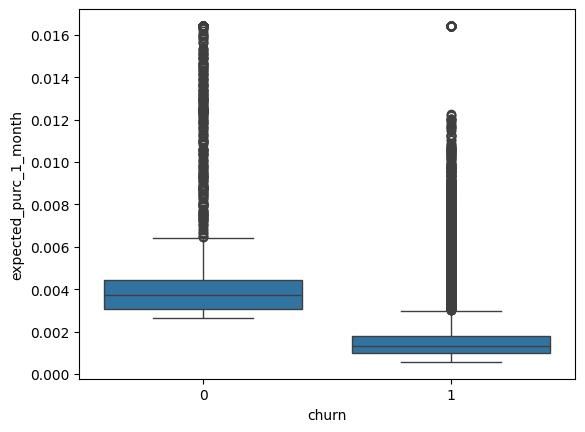

In [108]:
# CLV Feature Analysis
sns.boxplot(x="churn", y="expected_purc_1_month", data=df)

* low expected purchase → high churn

<Axes: xlabel='days_since_last_purchase', ylabel='Count'>

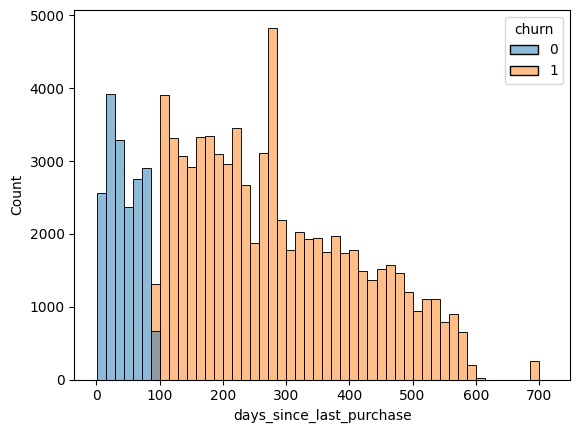

In [113]:
# Churn Risk Pattern
sns.histplot(data=df, x="days_since_last_purchase", hue="churn", bins=50)

## Categorical Variables vs Churn

Repeat customers show slightly lower churn rates compared to one-time buyers.

However, the majority of churn still comes from **customers who purchased only once**.


In [118]:
## Repeat Customer Analysis
pd.crosstab(df["is_repeat_customer"], df["churn"], normalize="index")

churn,0,1
is_repeat_customer,,
0,0.19706,0.80294
1,0.21921,0.78079


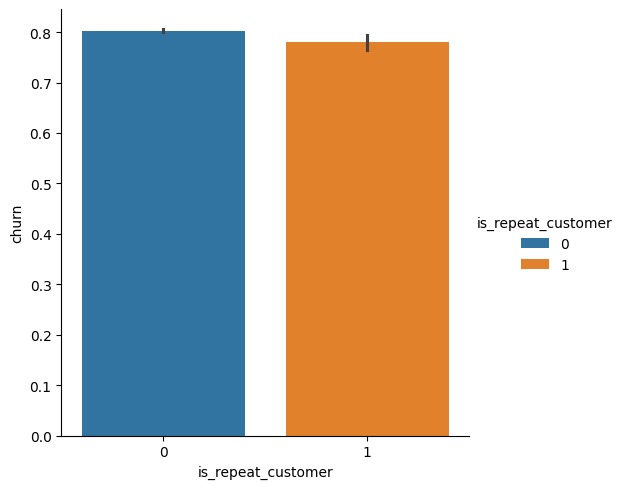

In [119]:
sns.catplot(x="is_repeat_customer", y="churn", data=df, kind="bar", hue="is_repeat_customer");

* Repeat customers churn a little less.

## Correlation Analysis

Correlation analysis helps detect multicollinearity between variables.

Highly correlated variables may introduce redundancy and reduce model stability.

These variables are later considered during **feature selection**.

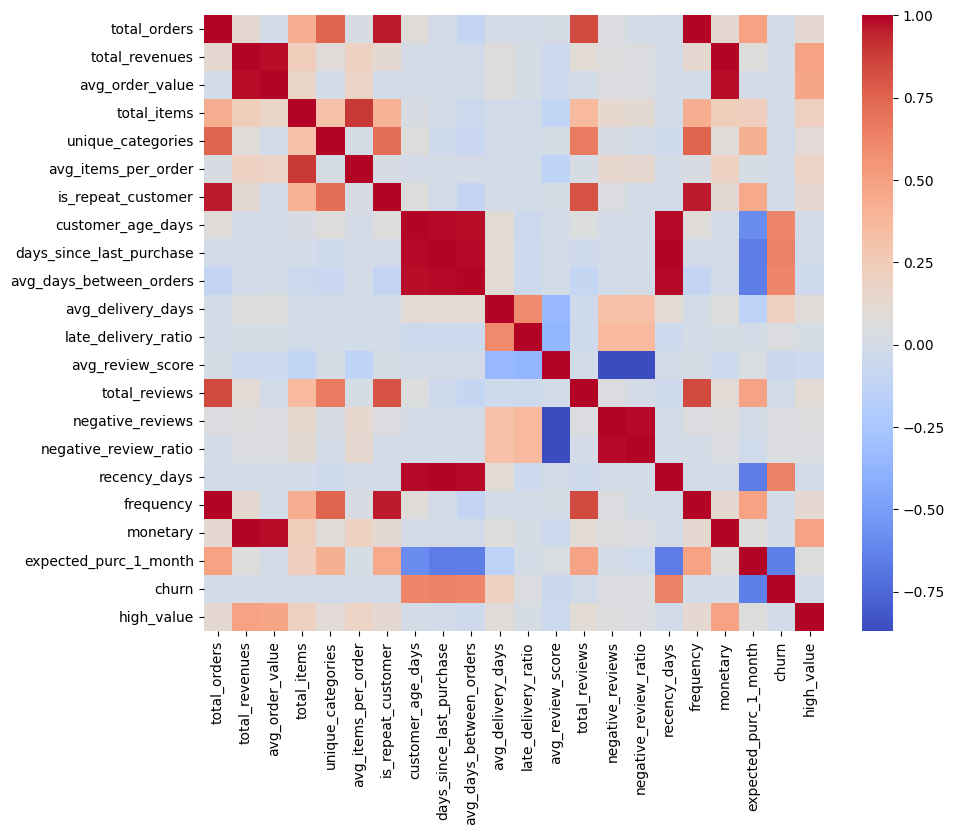

In [126]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False);

# 6. Feature Engineering

Additional behavioral features are created to improve model performance.

Examples include:

- purchase velocity
- recency ratio
- order density
- delivery risk
- sentiment risk

These engineered features help the model capture **complex behavioral patterns**.


In [130]:
# Customer shopping speed
df["purchase_velocity"] = df["frequency"] / (df["customer_age_days"] + 1)
# is the customer active or passive?
df["recency_ratio"] = df["days_since_last_purchase"] / (df["customer_age_days"] + 1)
# Customer's shopping pattern
df["order_density"] = df["frequency"] / (df["avg_days_between_orders"] + 1)
# delivery risk
df["delivery_risk"] = df["avg_delivery_days"] * df["late_delivery_ratio"]
# Customer satisfaction
df["sentiment_risk"] = (5 - df["avg_review_score"]) * df["negative_review_ratio"]

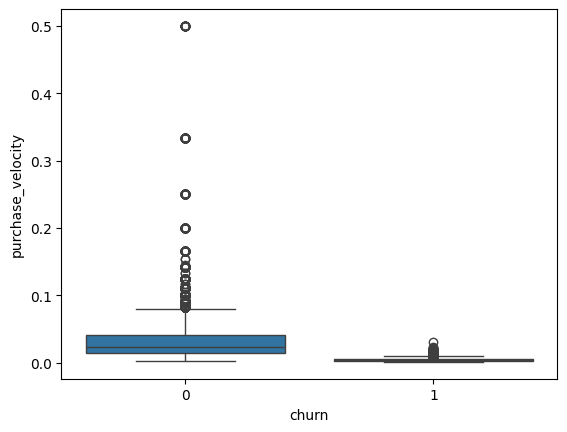

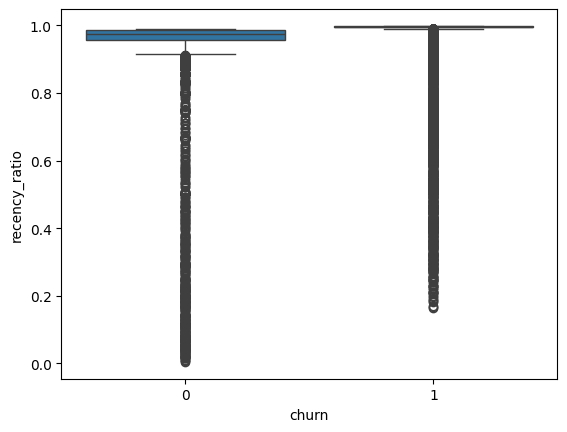

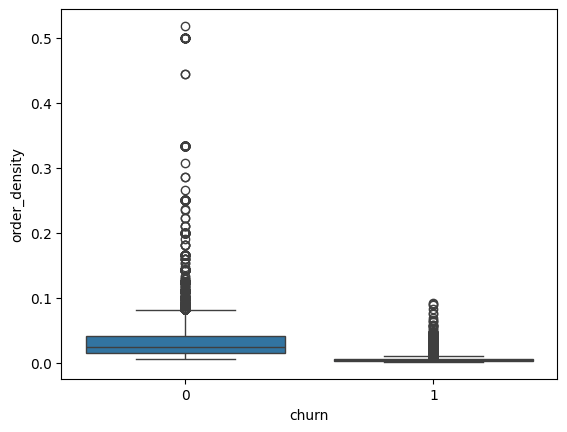

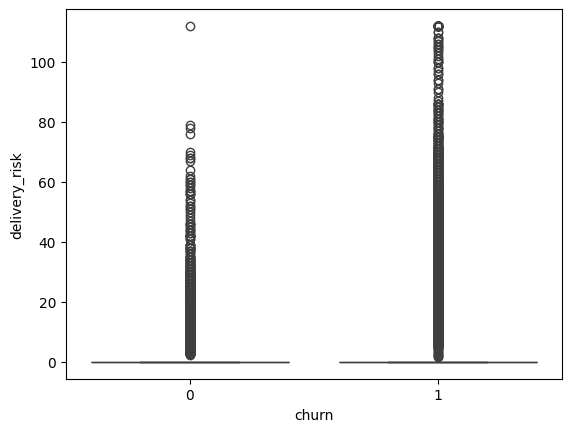

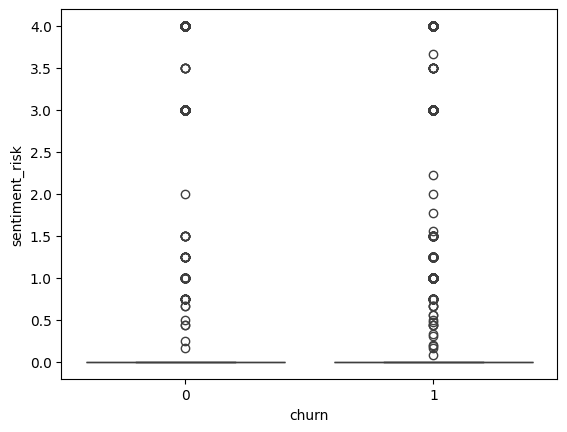

In [133]:
new_cols = ["purchase_velocity", "recency_ratio", "order_density", "delivery_risk", "sentiment_risk"]

for col in new_cols:
    sns.boxplot(x="churn", y=col, data=df)
    plt.show()

# 7. Feature Selection

Feature importance analysis is performed using a **Random Forest model**.

Highly correlated variables are removed to prevent multicollinearity.

The final feature set focuses on variables that provide the **highest predictive power for churn**.

In [136]:
X = df.drop("churn", axis=1)
y = df["churn"]

model = RandomForestClassifier()
model.fit(X, y)

imp = pd.Series(model.feature_importances_, index=X.columns)
imp.sort_values(ascending=False)

recency_days               0.21441
days_since_last_purchase   0.16081
expected_purc_1_month      0.12165
customer_age_days          0.11114
purchase_velocity          0.10958
avg_days_between_orders    0.10762
recency_ratio              0.09308
order_density              0.07323
total_orders               0.00266
is_repeat_customer         0.00226
avg_delivery_days          0.00096
unique_categories          0.00077
delivery_risk              0.00063
frequency                  0.00057
total_reviews              0.00027
late_delivery_ratio        0.00015
avg_review_score           0.00004
negative_reviews           0.00003
negative_review_ratio      0.00002
sentiment_risk             0.00002
total_items                0.00002
avg_order_value            0.00002
monetary                   0.00002
total_revenues             0.00002
high_value                 0.00001
avg_items_per_order        0.00000
dtype: float64

In [138]:
df[[
    "customer_age_days",
    "days_since_last_purchase",
    "recency_days"
]].corr()

,customer_age_days,days_since_last_purchase,recency_days
customer_age_days,1.00000,0.98662,0.98650
days_since_last_purchase,0.98662,1.00000,0.99988
recency_days,0.98650,0.99988,1.00000


The three variables with the highest significance level for the model have a correlation above 90%.

In [142]:
select_cols = [
   # customer activity
    "days_since_last_purchase",
    "avg_days_between_orders",
    
    # purchase rhythm
    "order_density",
    "purchase_velocity",
    
    # CLV signal
    "expected_purc_1_month",
    
    # purchase volume
    "frequency",
    "total_orders",
    
    # experience
    "delivery_risk",
    
    # engagement
    "total_reviews",
    "churn"    
]

df_new = df[select_cols]
df_new.head()

,days_since_last_purchase,avg_days_between_orders,order_density,purchase_velocity,expected_purc_1_month,frequency,total_orders,delivery_risk,total_reviews,churn
0,112,112.00000,0.00885,0.00885,0.00236,1.00000,1.00000,0.00000,1.00000,1
1,115,115.00000,0.00862,0.00862,0.00232,1.00000,1.00000,0.00000,1.00000,1
2,537,537.00000,0.00186,0.00186,0.00074,1.00000,1.00000,0.00000,1.00000,1
3,321,321.00000,0.00311,0.00311,0.00113,1.00000,1.00000,0.00000,1.00000,1
4,288,288.00000,0.00346,0.00346,0.00123,1.00000,1.00000,0.00000,1.00000,1


# 8. Encoding and Scaling

Categorical variables are encoded using **Label Encoding**.

Rare categories are grouped using **Rare Encoding** to prevent overfitting.

Numerical variables are standardized using **StandardScaler** to ensure consistent feature scales.

In [146]:
cat_cols, num_cols, cat_but_car = grab_col_names(df_new, cat_th=7, car_th=20)

Observations: 93358
Variables: 10
cat_cols: 4
num_cols: 6
cat_but_car: 0
num_but_cat: 4


In [147]:
cat_cols = [col for col in cat_cols if col !="churn"]
cat_cols

['frequency', 'total_orders', 'total_reviews']

In [149]:
for i in cat_cols:
    print(df_new[i].value_counts(normalize=True))

frequency
1.00000   0.96999
2.00000   0.02756
3.00000   0.00195
3.50000   0.00050
Name: proportion, dtype: float64
total_orders
1.00000   0.97000
2.00000   0.02756
3.00000   0.00194
3.50000   0.00050
Name: proportion, dtype: float64
total_reviews
1.00000   0.96772
2.00000   0.02354
0.00000   0.00678
3.00000   0.00151
3.50000   0.00045
Name: proportion, dtype: float64


In [150]:
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(f"\n--- {col} ---")
        
        print(pd.DataFrame({
            "COUNT": dataframe[col].value_counts(),
            "RATIO": dataframe[col].value_counts()/len(dataframe),
            "TARGET_MEAN": dataframe.groupby(col)[target].mean()
        }))

In [151]:
rare_analyser(df_new, "churn", cat_cols)


--- frequency ---
           COUNT   RATIO  TARGET_MEAN
frequency                            
1.00000    90556 0.96999      0.80294
2.00000     2573 0.02756      0.78469
3.00000      182 0.00195      0.77473
3.50000       47 0.00050      0.59574

--- total_orders ---
              COUNT   RATIO  TARGET_MEAN
total_orders                            
1.00000       90557 0.97000      0.80294
2.00000        2573 0.02756      0.78469
3.00000         181 0.00194      0.77348
3.50000          47 0.00050      0.59574

--- total_reviews ---
               COUNT   RATIO  TARGET_MEAN
total_reviews                            
0.00000          633 0.00678      0.84518
1.00000        90344 0.96772      0.80324
2.00000         2198 0.02354      0.75933
3.00000          141 0.00151      0.72340
3.50000           42 0.00045      0.59524


In [152]:
def rare_encoder(dataframe, rare_prec, cat_cols):
    for col in cat_cols:
        data = pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                             "RATIO": dataframe[col].value_counts()/len(dataframe)})
        rare_labels = data[data["RATIO"] <= rare_prec].index
        most_common_label = data["RATIO"].idxmax()
        dataframe[col] = dataframe[col].replace(rare_labels, most_common_label)
    return dataframe

In [153]:
df_new = rare_encoder(df_new, 0.01, cat_cols)

for i in cat_cols:
    print(df_new[i].value_counts(normalize=True))

frequency
1.00000   0.97244
2.00000   0.02756
Name: proportion, dtype: float64
total_orders
1.00000   0.97244
2.00000   0.02756
Name: proportion, dtype: float64
total_reviews
1.00000   0.97646
2.00000   0.02354
Name: proportion, dtype: float64


C:\Users\okand\AppData\Local\Temp\ipykernel_13216\1919065744.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[col] = dataframe[col].replace(rare_labels, most_common_label)
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\1919065744.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[col] = dataframe[col].replace(rare_labels, most_common_label)
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\1919065744.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

In [164]:
## Train_test_split

X = df_new.drop("churn", axis=1)
y = df_new["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=15)

In [166]:
label_encoder_cols=[]
scaler_cols = []

for col in X_train.columns.tolist():
    if col in cat_cols:
        label_encoder_cols.append(col)
    else:
        scaler_cols.append(col)

In [168]:
encoders = {}
for col in label_encoder_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
    encoders[col] = LabelEncoder()
    X_train[col] = encoders[col].fit_transform(X_train[col])
    X_test[col] = encoders[col].transform(X_test[col])

In [170]:
scalers = {}
for col in scaler_cols:
    scalers[col] = StandardScaler()
    X_train[[col]] = scalers[col].fit_transform(X_train[[col]])
    X_test[[col]] = scalers[col].transform(X_test[[col]])

# 9. Model Building

A **LightGBM classifier** is used for churn prediction.

LightGBM is selected because:

- it performs well on tabular datasets
- handles nonlinear relationships effectively
- trains efficiently on large datasets

Class imbalance is handled using **scale_pos_weight**.

Model performance is evaluated using classification metrics such as:

- precision
- recall
- f1-score


In [173]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 0.24511765266266552


In [175]:


lgbm_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=6,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 52485, number of negative: 12865
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1401
[LightGBM] [Info] Number of data points in the train set: 65350, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803137 -> initscore=1.406017
[LightGBM] [Info] Start training from score 1.406017
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, max_depth=6,
               min_child_samples=30, n_estimators=500, n_jobs=-1,
               objective='binary', random_state=42, reg_alpha=0.1,
               reg_lambda=0.1, scale_pos_weight=0.24511765266266552,
               subsample=0.8)

In [177]:
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5594
           1       1.00      1.00      1.00     22414

    accuracy                           1.00     28008
   macro avg       1.00      1.00      1.00     28008
weighted avg       1.00      1.00      1.00     28008

ROC AUC: 1.0
Confusion Matrix:
[[ 5594     0]
 [    1 22413]]


# 10. Functionalizing the Pipeline

To ensure reproducibility and scalability, the entire pipeline is converted into reusable functions.

The pipeline includes:

- dataset creation
- preprocessing
- feature engineering
- encoding and scaling
- model training
- churn probability prediction

This allows the churn prediction process to be **applied to new incoming data automatically**.

In [181]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    
    # Capturing features based on data types.
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and str(dataframe[col].dtypes) in ["int64", "float64", "int32"]]
    cat_but_car = [col for col in dataframe.columns if
                   dataframe[col].nunique() > car_th and str(dataframe[col].dtypes) in ["category", "object"]]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["int64", "float64", "int32"]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [183]:
def outlier_threshold(dataframe, col_name, q1 = 0.01, q3 = 0.99):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interqunatile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interqunatile_range
    low_limit = quartile1 - 1.5 * interqunatile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_threshold(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def replace_with_threshold(dataframe, variable):
    low_limit, up_limit = outlier_threshold(dataframe, variable)
    #dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [185]:
def rare_encoder(dataframe, rare_prec, cat_cols):
    for col in cat_cols:
        data = pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                             "RATIO": dataframe[col].value_counts()/len(dataframe)})
        rare_labels = data[data["RATIO"] <= rare_prec].index
        most_common_label = data["RATIO"].idxmax()
        dataframe[col] = dataframe[col].replace(rare_labels, most_common_label)
    return dataframe

In [187]:
def create_data_set(dataframe):
    # SQL Connection
    conn = pymysql.connect(database = "olist", user = "root", password = "160510", local_infile=True)
    cursor = conn.cursor()

    date_cols = ["purchase_ts","approved_ts","carrier_ts","delivered_ts","review_creation_date"]
    for c in date_cols:
        if c in df_all.columns:
            df_all[c] = pd.to_datetime(df_all[c], errors="coerce")

    cat_cols = ["main_category_by_item","main_category_by_revenue","order_type","all_categories"]
    for c in cat_cols:
        if c in df_all.columns:
            df_all[c] = df_all[c].astype(str).str.replace(r"[\r\n\t]", "", regex=True).str.strip()
    
    # ---- Transaction Features -----
    cust_tf = dataframe.groupby("customer_unique_id").agg(
        total_orders = ("order_id", "nunique"),
        total_revenues = ("total_payment", "sum"),
        avg_order_value=("total_payment","mean"),
        total_items = ("item_count", "sum"),
        unique_categories = ("main_category_by_revenue", "nunique")
    )
    
    cust_tf["avg_items_per_order"] = cust_tf["total_items"] / cust_tf["total_orders"]
    cust_tf["is_repeat_customer"] = (cust_tf["total_orders"] > 1).astype(int)

    # ----- Time Features ------
    analysis_date = dataframe["purchase_ts"].max() + pd.Timedelta(days=1)
    
    cust_time = dataframe.groupby("customer_unique_id").agg(
        first_purchase = ("purchase_ts", "min"),
        last_purchase = ("purchase_ts", "max"),
        total_orders = ("order_id", "nunique")
    )
    
    cust_time["customer_age_days"] = (analysis_date - cust_time["first_purchase"]).dt.days
    
    cust_time["days_since_last_purchase"] = (analysis_date - cust_time["last_purchase"]).dt.days
    
    cust_time["avg_days_between_orders"] = (cust_time["customer_age_days"] / cust_time["total_orders"])
    
    cust_time.drop("total_orders", axis=1, inplace=True)

    # --- Delivery Features ----
    cust_delivery = dataframe.groupby("customer_unique_id").agg(
        avg_delivery_days=("days_to_deliver","mean"),
        late_delivery_ratio=("is_late","mean")
    )

    # --- Review Features -----
    cust_reviews = dataframe.groupby("customer_unique_id").agg(
        avg_review_score=("review_score", "mean"),
        total_reviews=("review_score", "count"),
        negative_reviews=("review_score", 
                          lambda x: (x <= 2).sum() if x.notna().any() else np.nan)
    )
    
    cust_reviews["negative_review_ratio"] = (
        cust_reviews["negative_reviews"] / cust_reviews["total_reviews"]
    )

    # --- RFM Features ---
    rfm_df = pd.read_sql("SELECT * FROM rfm_customer_segments", conn)
    rfm_df=rfm_df[["customer_unique_id", "recency_days", "frequency", "monetary"]].copy()
    rfm_df.set_index("customer_unique_id", inplace=True)

    # --- CLV Features ---
    clv_df = pd.read_sql("SELECT * FROM nbd_summary", conn)
    clv_df=clv_df[["customer_unique_id", "expected_purc_1_month"]].copy()
    clv_df.set_index("customer_unique_id", inplace=True)

    # --- Joining ----
    df = (
        cust_tf
        .join(cust_time)
        .join(cust_delivery)
        .join(cust_reviews)
        .join(rfm_df)
        .join(clv_df)
    )

    # --- Target Feature ---
    churn_threshold = 90
    df["churn"] = (df["days_since_last_purchase"] > churn_threshold).astype(int)
    df.reset_index(inplace=True)
    return df

In [220]:
df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)
df_all.head()

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\383586695.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql("SELECT * FROM v_order_fact_delivered", conn)


,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.00000,0,58.90000,13.29000,72.19000,1,72.19000,1.00000,2.00000,0.00000,5.00000,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.00000,0,239.90000,19.93000,259.83000,1,259.83000,1.00000,3.00000,0.00000,4.00000,,,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.00000,0,199.00000,17.87000,216.87000,1,216.87000,1.00000,5.00000,0.00000,5.00000,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.00000,0,12.99000,12.79000,25.78000,1,25.78000,1.00000,2.00000,0.00000,4.00000,,,2018-08-15 00:00:00,perfumery\r,perfumery\r,1,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.00000,0,199.90000,18.14000,218.04000,1,218.04000,1.00000,3.00000,0.00000,5.00000,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1,Single,garden_tools\r,varzea paulista,SP


In [221]:
df = create_data_set(df_all)
df.head()

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2394463384.py:64: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rfm_df = pd.read_sql("SELECT * FROM rfm_customer_segments", conn)
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2394463384.py:69: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  clv_df = pd.read_sql("SELECT * FROM nbd_summary", conn)


,customer_unique_id,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer,first_purchase,last_purchase,customer_age_days,days_since_last_purchase,avg_days_between_orders,avg_delivery_days,late_delivery_ratio,avg_review_score,total_reviews,negative_reviews,negative_review_ratio,recency_days,frequency,monetary,expected_purc_1_month,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90000,141.90000,1,1,1.00000,0,2018-05-10 10:56:27,2018-05-10 10:56:27,112,112,112.00000,6.00000,0.00000,5.00000,1,0.00000,0.00000,112,1,141.90000,0.00236,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19000,27.19000,1,1,1.00000,0,2018-05-07 11:11:27,2018-05-07 11:11:27,115,115,115.00000,3.00000,0.00000,4.00000,1,0.00000,0.00000,115,1,27.19000,0.00232,1
2,0000f46a3911fa3c0805444483337064,1,86.22000,86.22000,1,1,1.00000,0,2017-03-10 21:05:03,2017-03-10 21:05:03,537,537,537.00000,26.00000,0.00000,3.00000,1,0.00000,0.00000,537,1,86.22000,0.00074,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62000,43.62000,1,1,1.00000,0,2017-10-12 20:29:41,2017-10-12 20:29:41,321,321,321.00000,20.00000,0.00000,4.00000,1,0.00000,0.00000,321,1,43.62000,0.00113,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89000,196.89000,1,1,1.00000,0,2017-11-14 19:45:42,2017-11-14 19:45:42,288,288,288.00000,13.00000,0.00000,5.00000,1,0.00000,0.00000,288,1,196.89000,0.00123,1


In [224]:
def data_prep(dataframe):
    df_copy = dataframe.copy()
    df_copy.drop(["customer_unique_id", "first_purchase", "last_purchase"], axis=1, inplace=True)
    cat_cols, num_cols, cat_but_car = grab_col_names(df_copy, cat_th=7, car_th=20)
    ## --- fill missing values ---
    df_copy["negative_reviews"] = df_copy["negative_reviews"].fillna(0)
    df_copy["negative_review_ratio"] = df_copy["negative_review_ratio"].fillna(0)
    df_copy["avg_review_score"] = df_copy["avg_review_score"].fillna(df_copy["avg_review_score"].median())
    df_copy["avg_delivery_days"] = df_copy["avg_delivery_days"].fillna(df_copy["avg_delivery_days"].median())
    df_copy["avg_order_value"] = df_copy["avg_order_value"].fillna(df_copy["avg_order_value"].median())
    ## --- Outlier Detection --- 
    for col in num_cols:
        replace_with_threshold(df, col)
    ## -- Feature Extraction ---
    # Customer shopping speed
    df_copy["purchase_velocity"] = df_copy["frequency"] / (df_copy["customer_age_days"] + 1)
    # is the customer active or passive?
    df_copy["recency_ratio"] = df_copy["days_since_last_purchase"] / (df_copy["customer_age_days"] + 1)
    # Customer's shopping pattern
    df_copy["order_density"] = df_copy["frequency"] / (df_copy["avg_days_between_orders"] + 1)
    # delivery risk
    df_copy["delivery_risk"] = df_copy["avg_delivery_days"] * df_copy["late_delivery_ratio"]
    # Customer satisfaction
    df_copy["sentiment_risk"] = (5 - df_copy["avg_review_score"]) * df_copy["negative_review_ratio"]

    ## --- Feature Selection ---
    select_cols = [
       # customer activity
        "days_since_last_purchase",
        "avg_days_between_orders",
        
        # purchase rhythm
        "order_density",
        "purchase_velocity",
        
        # CLV signal
        "expected_purc_1_month",
        
        # purchase volume
        "frequency",
        "total_orders",
        
        # experience
        "delivery_risk",
        
        # engagement
        "total_reviews",
        "churn"    
    ]
    
    df_new = df_copy[select_cols]
    
    return df_new

In [226]:
df_new = data_prep(df)
df_new.head()

Observations: 93358
Variables: 21
cat_cols: 4
num_cols: 17
cat_but_car: 0
num_but_cat: 4


C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2752709363.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2752709363.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2752709363.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1426.5' has dtype incompatible with int64, please explicitly cast to a compatible d

,days_since_last_purchase,avg_days_between_orders,order_density,purchase_velocity,expected_purc_1_month,frequency,total_orders,delivery_risk,total_reviews,churn
0,112,112.00000,0.00885,0.00885,0.00236,1,1,0.00000,1,1
1,115,115.00000,0.00862,0.00862,0.00232,1,1,0.00000,1,1
2,537,537.00000,0.00186,0.00186,0.00074,1,1,0.00000,1,1
3,321,321.00000,0.00311,0.00311,0.00113,1,1,0.00000,1,1
4,288,288.00000,0.00346,0.00346,0.00123,1,1,0.00000,1,1


In [228]:
def encoding_and_scaling(dataframe):
    # --- Encodering And Scaling---
    cat_cols, num_cols, cat_but_car = grab_col_names(dataframe, cat_th=7, car_th=20)
    cat_cols = [col for col in cat_cols if col !="churn"]
    dataframe = rare_encoder(dataframe, 0.01, cat_cols)

    ## Train_test_split
    
    X = dataframe.drop("churn", axis=1)
    y = dataframe["churn"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=15)

    label_encoder_cols=[]
    scaler_cols = []
    
    for col in X_train.columns.tolist():
        if col in cat_cols:
            label_encoder_cols.append(col)
        else:
            scaler_cols.append(col)

    fatures = X_train.columns.tolist()
    
    encoders = {}
    for col in label_encoder_cols:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)
        encoders[col] = LabelEncoder()
        X_train[col] = encoders[col].fit_transform(X_train[col])
        X_test[col] = encoders[col].transform(X_test[col])


    scalers = {}
    for col in scaler_cols:
        scalers[col] = StandardScaler()
        X_train[[col]] = scalers[col].fit_transform(X_train[[col]])
        X_test[[col]] = scalers[col].transform(X_test[[col]])

    return fatures, encoders, scalers, X_train, X_test, y_train, y_test

In [232]:
fatures, encoders, scalers, X_train, X_test, y_train, y_test = encoding_and_scaling(df_new)

Observations: 93358
Variables: 10
cat_cols: 1
num_cols: 9
cat_but_car: 0
num_but_cat: 1


In [234]:
def build_model(X_train, X_test, y_train, y_test):
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()

    scale_pos_weight = neg / pos

    lgbm_model = LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
    
    lgbm_model.fit(X_train, y_train)

    y_pred = lgbm_model.predict(X_test)
    y_prob = lgbm_model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return lgbm_model

In [236]:
model = build_model(X_train, X_test, y_train, y_test)

[LightGBM] [Info] Number of positive: 52485, number of negative: 12865
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1430
[LightGBM] [Info] Number of data points in the train set: 65350, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803137 -> initscore=1.406017
[LightGBM] [Info] Start training from score 1.406017
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [246]:
def create_probs(dataframe, model, encoders, scalers):
    df_copy = dataframe.copy()
    df_copy = create_data_set(df_copy)
    df_new = data_prep(df_copy)
    
    # --- Encodering And Scaling---
    cat_cols, num_cols, cat_but_car = grab_col_names(df_new, cat_th=7, car_th=20)
    cat_cols = [col for col in cat_cols if col !="churn"]
    df_new = rare_encoder(df_new, 0.01, cat_cols)


    X = df_new.drop("churn", axis=1)

    for col, encoder in encoders.items():
        X[col] = encoder.transform(X[col])

    for col, scaler in scalers.items():
        X[[col]] = scaler.transform(X[[col]])

    y_pred = model.predict(X)

    y_prob = model.predict_proba(X)[:, 1]

    X["chrurn_prob"] = y_prob
    X["chrurn_pred"] = y_pred

    df_copy["chrurn_prob"] = X["chrurn_prob"].copy()
    df_copy["churn_pred"] = X["chrurn_pred"].copy()

    return df_copy
    

In [248]:
df_2 = create_probs(df_all, model, encoders, scalers)

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2394463384.py:64: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rfm_df = pd.read_sql("SELECT * FROM rfm_customer_segments", conn)
C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2394463384.py:69: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  clv_df = pd.read_sql("SELECT * FROM nbd_summary", conn)


Observations: 93358
Variables: 21
cat_cols: 4
num_cols: 17
cat_but_car: 0
num_but_cat: 4
Observations: 93358
Variables: 10
cat_cols: 1
num_cols: 9
cat_but_car: 0
num_but_cat: 1


In [249]:
df_2.head()

,customer_unique_id,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer,first_purchase,last_purchase,customer_age_days,days_since_last_purchase,avg_days_between_orders,avg_delivery_days,late_delivery_ratio,avg_review_score,total_reviews,negative_reviews,negative_review_ratio,recency_days,frequency,monetary,expected_purc_1_month,churn,chrurn_prob,churn_pred
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90000,141.90000,1,1,1.00000,0,2018-05-10 10:56:27,2018-05-10 10:56:27,112,112,112.00000,6.00000,0.00000,5.00000,1,0.00000,0.00000,112,1,141.90000,0.00236,1,0.99999,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19000,27.19000,1,1,1.00000,0,2018-05-07 11:11:27,2018-05-07 11:11:27,115,115,115.00000,3.00000,0.00000,4.00000,1,0.00000,0.00000,115,1,27.19000,0.00232,1,0.99999,1
2,0000f46a3911fa3c0805444483337064,1,86.22000,86.22000,1,1,1.00000,0,2017-03-10 21:05:03,2017-03-10 21:05:03,537,537,537.00000,26.00000,0.00000,3.00000,1,0.00000,0.00000,537,1,86.22000,0.00074,1,0.99999,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62000,43.62000,1,1,1.00000,0,2017-10-12 20:29:41,2017-10-12 20:29:41,321,321,321.00000,20.00000,0.00000,4.00000,1,0.00000,0.00000,321,1,43.62000,0.00113,1,0.99999,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89000,196.89000,1,1,1.00000,0,2017-11-14 19:45:42,2017-11-14 19:45:42,288,288,288.00000,13.00000,0.00000,5.00000,1,0.00000,0.00000,288,1,196.89000,0.00123,1,0.99999,1


In [252]:
## accuracy
df_2["churn_pred"].sum() / df_2["churn"].sum()

0.9999866486868983

In [257]:
df_2.to_csv("churn_prob.csv", index=False)

# Final Output

The final dataset includes:

- churn prediction
- churn probability

These outputs can be integrated into:

- CRM systems
- retention campaigns
- marketing automation tools
- customer segmentation pipelines

The model enables companies to **identify high-risk customers and take proactive retention actions**.

# Database Upload & Integration

In [255]:
q_create_table_churn = """
CREATE TABLE IF NOT EXISTS customer_churn_features (

    customer_unique_id VARCHAR(50) PRIMARY KEY,

    total_orders INT,
    total_revenues DECIMAL(12,2),
    avg_order_value DECIMAL(12,2),

    total_items INT,
    unique_categories INT,
    avg_items_per_order DECIMAL(10,2),

    is_repeat_customer TINYINT,

    first_purchase DATETIME,
    last_purchase DATETIME,

    customer_age_days INT,
    days_since_last_purchase INT,
    avg_days_between_orders DECIMAL(10,2),

    avg_delivery_days DECIMAL(10,2),
    late_delivery_ratio DECIMAL(10,4),

    avg_review_score DECIMAL(3,2),
    total_reviews INT,
    negative_reviews INT,
    negative_review_ratio DECIMAL(10,4),

    recency_days INT,
    frequency INT,
    monetary DECIMAL(12,2),

    expected_purc_1_month DECIMAL(10,5),

    churn TINYINT,
    chrurn_prob DECIMAL(10,5),
    churn_pred TINYINT

);
"""

cursor.execute(q_create_table_churn)
conn.commit()

In [259]:
q_load_data_churn ="""
LOAD DATA LOCAL INFILE 'C:/Users/okand/Desktop/ecommerce/churn_prob.csv'
INTO TABLE customer_churn_features
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;
"""

cursor.execute(q_load_data_churn)
conn.commit()

In [261]:
pd.read_sql("SELECT * FROM customer_churn_features LIMIT 10;", conn)

C:\Users\okand\AppData\Local\Temp\ipykernel_13216\2250609560.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SELECT * FROM customer_churn_features LIMIT 10;", conn)


,customer_unique_id,total_orders,total_revenues,avg_order_value,total_items,unique_categories,avg_items_per_order,is_repeat_customer,first_purchase,last_purchase,customer_age_days,days_since_last_purchase,avg_days_between_orders,avg_delivery_days,late_delivery_ratio,avg_review_score,total_reviews,negative_reviews,negative_review_ratio,recency_days,frequency,monetary,expected_purc_1_month,churn,chrurn_prob,churn_pred
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90000,141.90000,1,1,1.00000,0,2018-05-10 10:56:27,2018-05-10 10:56:27,112,112,112.00000,6.00000,0.00000,5.00000,1,0,0.00000,112,1,141.90000,0.00236,1,0.99999,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19000,27.19000,1,1,1.00000,0,2018-05-07 11:11:27,2018-05-07 11:11:27,115,115,115.00000,3.00000,0.00000,4.00000,1,0,0.00000,115,1,27.19000,0.00232,1,0.99999,1
2,0000f46a3911fa3c0805444483337064,1,86.22000,86.22000,1,1,1.00000,0,2017-03-10 21:05:03,2017-03-10 21:05:03,537,537,537.00000,26.00000,0.00000,3.00000,1,0,0.00000,537,1,86.22000,0.00074,1,0.99999,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62000,43.62000,1,1,1.00000,0,2017-10-12 20:29:41,2017-10-12 20:29:41,321,321,321.00000,20.00000,0.00000,4.00000,1,0,0.00000,321,1,43.62000,0.00113,1,0.99999,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89000,196.89000,1,1,1.00000,0,2017-11-14 19:45:42,2017-11-14 19:45:42,288,288,288.00000,13.00000,0.00000,5.00000,1,0,0.00000,288,1,196.89000,0.00123,1,0.99999,1
5,0004bd2a26a76fe21f786e4fbd80607f,1,166.98000,166.98000,1,1,1.00000,0,2018-04-05 19:33:16,2018-04-05 19:33:16,146,146,146.00000,2.00000,0.00000,4.00000,1,0,0.00000,146,1,166.98000,0.00200,1,0.99999,1
6,00050ab1314c0e55a6ca13cf7181fecf,1,35.38000,35.38000,1,1,1.00000,0,2018-04-20 12:57:23,2018-04-20 12:57:23,132,132,132.00000,7.00000,0.00000,4.00000,1,0,0.00000,132,1,35.38000,0.00214,1,0.99999,1
7,00053a61a98854899e70ed204dd4bafe,1,419.18000,419.18000,2,1,2.00000,0,2018-02-28 11:15:41,2018-02-28 11:15:41,183,183,183.00000,16.00000,0.00000,1.00000,1,1,1.00000,183,1,419.18000,0.00172,1,0.99999,1
8,0005e1862207bf6ccc02e4228effd9a0,1,150.12000,150.12000,1,1,1.00000,0,2017-03-04 23:32:12,2017-03-04 23:32:12,543,543,543.00000,5.00000,0.00000,4.00000,1,0,0.00000,543,1,150.12000,0.00073,1,0.99999,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76000,129.76000,1,1,1.00000,0,2018-03-12 15:22:12,2018-03-12 15:22:12,170,170,170.00000,54.00000,1.00000,1.00000,1,1,1.00000,170,1,129.76000,0.00181,1,0.99999,1
